<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Convolutional Denoising Autoencoder (MNIST)**

By the end of this lab you will be able to:

1.	Build a convolutional autoencoder for image-to-image mapping.
2.	Turn a reconstruction AE into a denoising AE (noisy → clean).
3.	Compare a learned denoiser to a classical baseline (box blur).
4.	Evaluate denoising quality with PSNR, and interpret results.
5.	Understand generalization: why a model trained at one noise level can fail at others.
6.	Implement residual learning.

Setup:

You will work on MNIST digits (28x28 grayscale). We treat denoising as a supervised mapping problem where targets are clean images but inputs are corrupted. Noise model: additive Gaussian noise.

## Imports

In [2]:
import math
from collections.abc import Callable, Sequence
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch import Tensor
from torchvision.transforms import v2

%matplotlib inline

device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)

cuda


## Dataset

In [3]:
data_dir = Path("./data/MNIST/")
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
train_data = torchvision.datasets.MNIST(
    root=data_dir, train=True, download=True, transform=transform
)
test_data_all = torchvision.datasets.MNIST(
    root=data_dir, train=False, download=True, transform=transform
)

test_data = torch.utils.data.Subset(test_data_all, list(range(1000)))

num_workers = 0
batch_size = 20
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 450kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


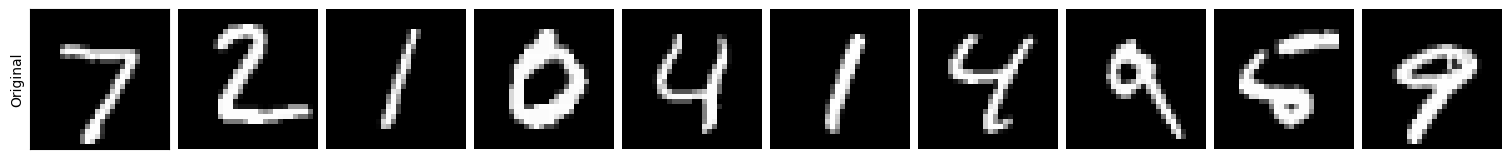

In [4]:
def show_image_batch(x: Tensor, row_title: str = "") -> None:
    fig, ax = plt.subplots(1, len(x), figsize=(1.5 * len(x), 1.5), constrained_layout=True, sharex=True, sharey=True)
    for i in range(len(x)):
        ax[i].imshow(np.squeeze(x[i].cpu()), cmap="gray")
        ax[i].axis("off")
    # Title left of row
    ax[0].axis("on")
    ax[0].xaxis.set_ticks([])
    ax[0].yaxis.set_ticks([])
    ax[0].set_ylabel(row_title, rotation=90)

vis_image_batch, _ = next(iter(test_loader))

show_image_batch(vis_image_batch[:10], "Original")

Let's define a function that adds zero-mean Gaussian noise with standard deviation sigma to the input images and then clips the result to keep pixel values in the [0,1] range.<br>
If `sigma` is a pair, use a different σ sampled uniformly from `sigma[0]` to `sigma[1]` for each image.

In [10]:
def corrupt_batch(
    x: Tensor, sigma: float | tuple[float, float], generator: torch.Generator
) -> Tensor:
    # TODO

    if isinstance(sigma, tuple):
        sigma = torch.rand(x.shape[0], generator=generator, device=x.device) * (sigma[1] - sigma[0]) + sigma[0]
    else:
        sigma = sigma * torch.ones(x.shape[0], device=x.device)
    sigma = sigma.view(-1, 1, 1, 1)
    x = x + torch.randn_like(x, generator=generator) * sigma
    return x.clamp(0.0, 1.0)

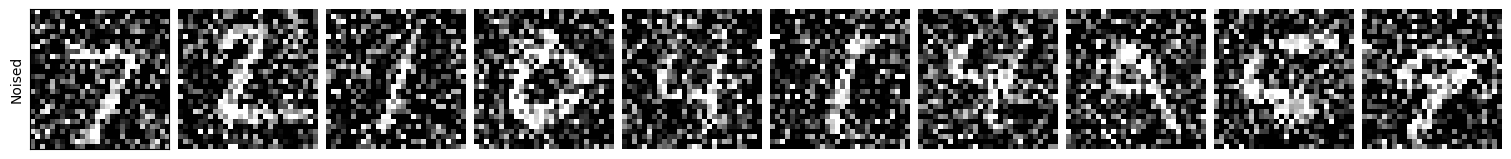

In [11]:
show_image_batch(corrupt_batch(vis_image_batch[:10], sigma=0.5, generator=torch.default_generator), "Noised")

## Evaluation and baseline

Let define Box Blur that applies a simple averaging filter, where each pixel is replaced by the mean of its surrounding k×k neighborhood, which smooths the image and reduces high-frequency noise but also softens edges.

In [24]:
def box_blur(x: Tensor, k: int = 3) -> Tensor:
    B, C, H, W = x.shape
    # TODO
    blur = nn.AvgPool2d(kernel_size=k, stride=1, padding=k // 2)

    return blur(x)

Let's define a function to visualize model predictions on sample images:

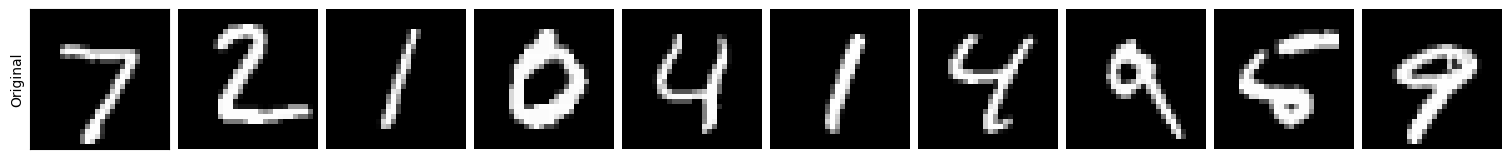

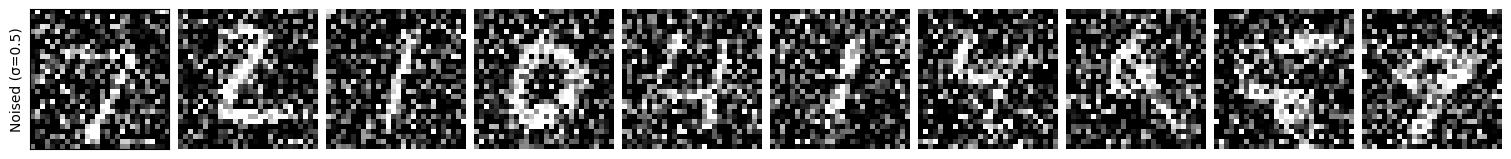

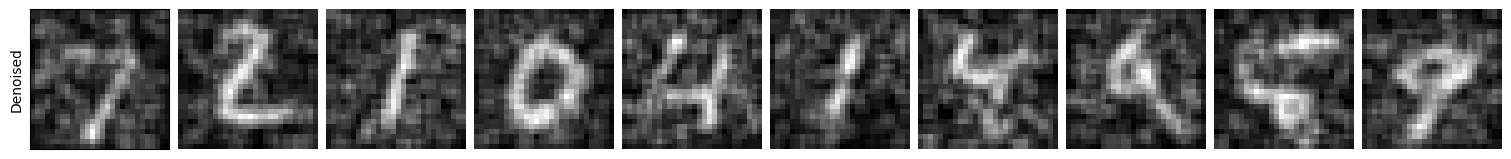

In [25]:
def visualize_model(
    model: Callable[[Tensor], Tensor], sigma: float, num_images: int = 10, seed: int = 1
) -> None:
    images, _ = next(iter(test_loader))
    images = images[:num_images].to(device)
    noisy = corrupt_batch(images, sigma=sigma, generator=torch.Generator(device=device).manual_seed(seed))
    with torch.no_grad():
        denoised = model(noisy)
    denoised = torch.clamp(denoised, 0.0, 1.0)
    show_image_batch(images, "Original")
    show_image_batch(noisy, f"Noised (σ={sigma})")
    show_image_batch(denoised, "Denoised")

visualize_model(box_blur, sigma=0.5)

Let's define Peak Signal-to-Noise Ratio (PSNR), a quality metric derived from the mean squared error between an output image x_hat and the clean reference x; it's measured in dB and higher PSNR means the output is closer to the clean image.

In [26]:
def psnr(x_hat: Tensor, x: Tensor, max_val: float = 1.0) -> float:
    # TODO
    psnr = 10 * torch.log10(max_val ** 2 / torch.mean((x_hat - x) ** 2))
    return psnr.item()

Let's define function eval_psnr_on_test_batches that tests a model across given noise levels by denoising noisy test images (optionally using residual subtraction) and printing the average PSNR for the noisy input, a box-blur baseline, and the model output against the clean images.

In [27]:
def eval_psnr_on_test_batches(
    denoiser: Callable[[Tensor], Tensor],
    sigmas: Sequence[float]
) -> dict[float, float]:
    results = dict[float, float]()
    for i, s in enumerate(sigmas):
        generator = torch.Generator(device=device).manual_seed(i)
        psnrs = []
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                noisy = corrupt_batch(images, sigma=s, generator=generator)
                denoised = denoiser(noisy)
                denoised = torch.clamp(denoised, 0.0, 1.0)
                psnrs.append(psnr(denoised, images))
        results[s] = float(np.mean(psnrs))
    print(", ".join(f"PSNR@σ={s} is: {results[s]:8.2f}" for s in sigmas))
    return results


all_results = dict[str, dict[float, float]]()  # Map from model name to sigma to PSNR.

In [28]:
print("Identity")
all_results["Identity"] = eval_psnr_on_test_batches(lambda x: x, sigmas=[0.0, 0.1, 0.2, 0.4, 0.6])
print("Box Blur")
all_results["Box Blur"] = eval_psnr_on_test_batches(box_blur, sigmas=[0.0, 0.1, 0.2, 0.4, 0.6])

Identity
PSNR@σ=0.0 is:      inf, PSNR@σ=0.1 is:    22.66, PSNR@σ=0.2 is:    16.74, PSNR@σ=0.4 is:    10.98, PSNR@σ=0.6 is:     8.24
Box Blur
PSNR@σ=0.0 is:    19.30, PSNR@σ=0.1 is:    18.35, PSNR@σ=0.2 is:    16.83, PSNR@σ=0.4 is:    13.78, PSNR@σ=0.6 is:    11.64


## Model

Let's build a Convolutional Denoising AutoEncoder:

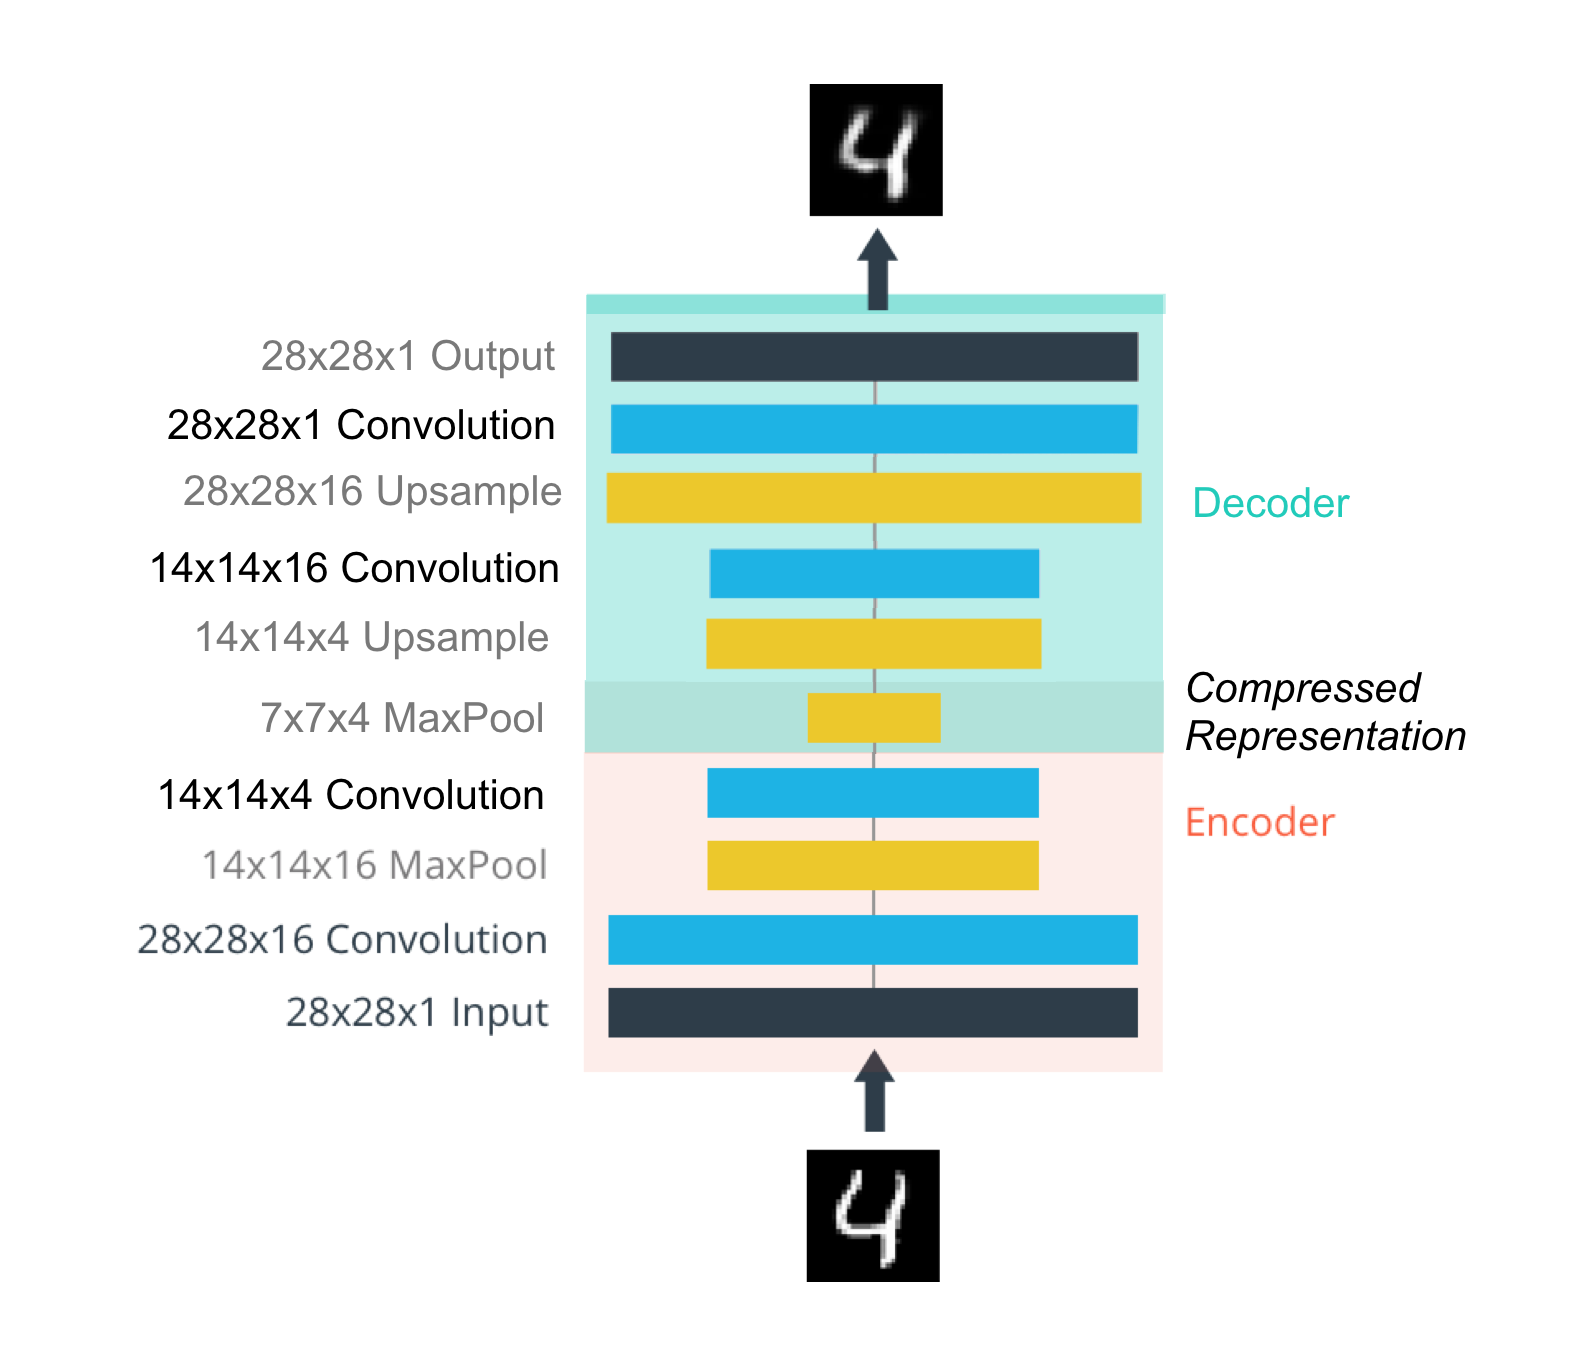

Your ConvAutoencoder consists of:
- Encoder: Conv → Pool → Conv → Pool (compression).
- Decoder: Upsample → Conv → Upsample → Conv.


What to observe:
- Pooling reduces spatial resolution and creates a bottleneck.
- The decoder restores resolution by upsampling.

In [29]:
class ConvAutoencoder(nn.Module):
    # TODO
    def __init__(self):
        super().__init__()
        self.layers_encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, 3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

        )
        self.layers_decoder = nn.Sequential(

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(4, 16, 3, padding=1, stride=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 1, 3, padding=1, stride=1),
            nn.Sigmoid()
        )
        pass

    def forward(self, x):
        # TODO
        return self.layers_decoder(self.layers_encoder(x))
    pass

PSNR@σ=0.0 is:     6.05, PSNR@σ=0.1 is:     6.05, PSNR@σ=0.2 is:     6.04, PSNR@σ=0.4 is:     6.02, PSNR@σ=0.6 is:     6.01


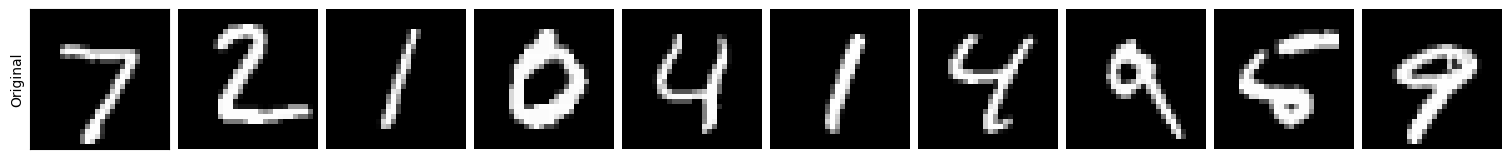

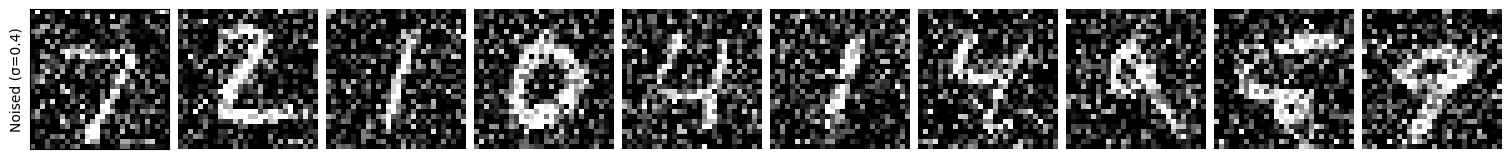

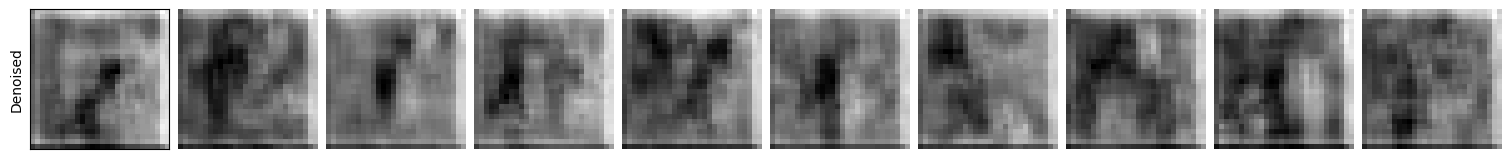

In [30]:
def call_model(model: nn.Module, x: Tensor, residual_learning: bool = False) -> Tensor:
    # TODO
    model.eval()
    if residual_learning:
      return x - model(x)
    else:
      return model(x)

eval_psnr_on_test_batches(partial(call_model, ConvAutoencoder().to(device)), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6])
visualize_model(partial(call_model, ConvAutoencoder().to(device)), sigma=0.4)

## Training
Let's define training function:

In [31]:
def create_and_train_net(sigma: float | tuple[float, float], residual_learning: bool = False, seed: int = 1) -> ConvAutoencoder:
    generator = torch.Generator(device=device).manual_seed(seed)
    model = ConvAutoencoder().to(device)
    model.train()

    if residual_learning:
        # TODO
        model.layers_decoder = nn.Sequential(*list(model.layers_decoder.children())[:-1])

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    n_epochs = 30
    for epoch in range(1, n_epochs + 1):
        total_loss, total_images = 0.0, 0
        for data in train_loader:
            images, _ = data
            images = images.to(device)
            noisy_images = corrupt_batch(images, sigma, generator)
            optimizer.zero_grad()

            pred = model(noisy_images)
            if residual_learning:
              loss = nn.MSELoss()(noisy_images - pred, images)
            else:
              loss = nn.MSELoss()(pred, images)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_images += images.size(0)

        avg_loss = total_loss / total_images
        print(f"Epoch: {epoch} \tTraining Loss: {avg_loss:.6f}")

    return model

Let's train a model only on Gaussian noise with σ = 0.4, so it becomes a "specialist" for that noise strength.

In [32]:
model1 = create_and_train_net(sigma=0.4)

all_results["Model1 (σ=0.4)"] = eval_psnr_on_test_batches(partial(call_model, model1), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6])
visualize_model(partial(call_model, model1), sigma=0.1)
visualize_model(partial(call_model, model1), sigma=0.4)

Epoch: 1 	Training Loss: 0.024865
Epoch: 2 	Training Loss: 0.015985
Epoch: 3 	Training Loss: 0.015264
Epoch: 4 	Training Loss: 0.014871
Epoch: 5 	Training Loss: 0.014582
Epoch: 6 	Training Loss: 0.014451
Epoch: 7 	Training Loss: 0.014350
Epoch: 8 	Training Loss: 0.014242
Epoch: 9 	Training Loss: 0.014169
Epoch: 10 	Training Loss: 0.014106


KeyboardInterrupt: 

Let's train a model on different noise strengths per image (σ sampled uniformly from 0 to 0.6), so it learns a more robust "blind denoiser" rather than a σ=0.4 specialist.

In [33]:
model2 = create_and_train_net(sigma=(0, 0.6))

all_results["Model2 (σ=0–0.6)"] = eval_psnr_on_test_batches(partial(call_model, model2), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6])
visualize_model(partial(call_model, model2), sigma=0.1)
visualize_model(partial(call_model, model2), sigma=0.4)

KeyboardInterrupt: 

Residual learning: instead of predicting the clean image, let's train the network to predict the residual (noise) r = noisy − clean.
Modify the training loop and the `call_model` wrapper accordingly.

In [34]:
model3 = create_and_train_net(sigma=(0, 0.6), residual_learning=True)

all_results["Model3 (residual, σ=0–0.6)"] = eval_psnr_on_test_batches(partial(call_model, model3), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6])
visualize_model(partial(call_model, model3), sigma=0.1)
visualize_model(partial(call_model, model3), sigma=0.4)

Epoch: 1 	Training Loss: 0.041574
Epoch: 2 	Training Loss: 0.039562
Epoch: 3 	Training Loss: 0.039427


KeyboardInterrupt: 

## Plot

Let's plot results:

In [ ]:
def plot_all_results(all_results: dict[str, dict[float, float]]):
    plt.figure(figsize=(8, 6))

    styles = ["k--", "gray", "o-", "s-", "^-", "d-", "x-"]
    for (model_name, results), style in zip(all_results.items(), styles):
        plt.plot(list(results.keys()), list(results.values()), style, label=model_name)

    plt.axvline(0.4, linestyle="--", alpha=0.3)

    plt.xlabel("Noise level σ")
    plt.ylabel("PSNR (dB)")
    plt.title("Denoising performance vs noise level")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_all_results(all_results)